# ============================================================
# DATA PREPARATION (CRISP-DM FASE 3)
# ============================================================
# OBJETIVO: 
**Limpiar, transformar y enriquecer los datos para modelado.**

- Cargamos el DataFrame 'eda' del notebook 01 (ya limpio de duplicados).

In [1]:
# ============================================================
# DATA PREPARATION (CRISP-DM FASE 3)
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# ===== NUEVO: Importar configuración central =====
import sys
import os
sys.path.append(os.path.abspath('..'))
from src import config
# =================================================

# Configuración de estilo (heredado de la Semana 1)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Configuración cargada.")
print(f"Ruta RAW: {config.RAW_DATA_PATH}")
print(f"Ruta INTERIM: {config.INTERIM_DATA_PATH}")
print(f"Ruta PROCESSED: {config.PROCESSED_DATA_PATH}")

✅ Configuración cargada.
Ruta RAW: c:\Users\Divios\Desktop\MEACD_ML1\S1\sales-marketing-churn-analysis\data\raw\sales_marketing_raw.csv
Ruta INTERIM: c:\Users\Divios\Desktop\MEACD_ML1\S1\sales-marketing-churn-analysis\data\interim\sales_marketing_clean.csv
Ruta PROCESSED: c:\Users\Divios\Desktop\MEACD_ML1\S1\sales-marketing-churn-analysis\data\processed\sales_marketing_processed.csv


#  CARGA INICIAL (SOLO SI SE EJECUTA DE FORMA INDEPENDIENTE)

- Si ejecutas este notebook de forma independiente, debes cargar los datos. 

- Si lo ejecutas justo después del 01 (manteniendo el kernel), puedes omitir esta celda y usar eda directamente.

In [2]:
# ============================================================
# CARGA DE DATOS (DESDE RAW O DESCARGANDO SI NO EXISTE)
# ============================================================
# ⚠️ Descomenta y ejecuta esta celda SOLO si no tienes 'eda' en memoria.
#    (Es decir, si NO has ejecutado el notebook 01 previamente)
# ============================================================
# Esta celda carga el dataset de manera inteligente:
# 1. Primero verifica si ya existe una copia local en data/raw/
# 2. Si existe, la carga directamente (más rápido)
# 3. Si no existe, la descarga desde Kaggle y la guarda para futuras ejecuciones
# ============================================================

# def load_or_download_data():
#     """
#     Función que carga el dataset desde la ruta RAW o lo descarga de Kaggle si no existe.
#     
#     Returns:
#         pd.DataFrame: DataFrame con los datos cargados.
#     """
#     
#     # ------------------------------------------------------------
#     # PASO 1: Obtener la ruta donde debería estar el archivo RAW
#     # ------------------------------------------------------------
#     # Usamos la variable definida en src/config.py para mantener consistencia
#     raw_path = config.RAW_DATA_PATH
#     
#     # ------------------------------------------------------------
#     # PASO 2: Verificar si el archivo ya existe localmente
#     # ------------------------------------------------------------
#     # Esto evita descargar el dataset cada vez que ejecutamos el notebook
#     if os.path.exists(raw_path):
#         print(f"✅ Cargando datos desde: {raw_path}")
#         
#         # Cargar el archivo CSV con los parámetros definidos en config
#         # - encoding: si no se especifica, usa 'utf-8'
#         # - sep: si no se especifica, usa coma ','
#         # - low_memory=False: mejora la lectura de archivos grandes
#         df = pd.read_csv(
#             raw_path,
#             encoding=config.ENCODING if config.ENCODING else 'utf-8',
#             sep=config.SEPARATOR if config.SEPARATOR else ',',
#             low_memory=False
#         )
#         
#         # Mostrar información del dataset cargado
#         print(f"   Dimensiones: {df.shape[0]:,} filas, {df.shape[1]} columnas")
#         
#         # Retornar el DataFrame para usarlo en el resto del notebook
#         return df
#     
#     # ------------------------------------------------------------
#     # PASO 3: Si NO existe localmente, descargar desde Kaggle
#     # ------------------------------------------------------------
#     else:
#         print("⚠️ Archivo RAW no encontrado. Descargando desde Kaggle...")
#         
#         # Importar kagglehub solo cuando sea necesario
#         import kagglehub
#         
#         # Descargar el dataset usando el identificador de Kaggle (definido en config)
#         path = kagglehub.dataset_download(config.KAGGLE_DATASET)
#         print(f"   Dataset descargado en: {path}")
#         
#         # ------------------------------------------------------------
#         # PASO 4: Buscar el archivo específico dentro de la carpeta descargada
#         # ------------------------------------------------------------
#         # Kaggle a veces incluye varios archivos, necesitamos encontrar el correcto
#         all_files = []
#         for dirname, _, filenames in os.walk(path):
#             for filename in filenames:
#                 all_files.append(os.path.join(dirname, filename))
#         
#         # Intentar usar el archivo esperado (definido en config.EXPECTED_FILENAME)
#         expected = config.EXPECTED_FILENAME
#         if expected and expected in [os.path.basename(f) for f in all_files]:
#             file_path = os.path.join(path, expected)
#             print(f"   Usando archivo esperado: {expected}")
#         else:
#             # Si no se encuentra, usar el primer archivo disponible como fallback
#             file_path = all_files[0]
#             print(f"   Usando archivo alternativo: {os.path.basename(file_path)}")
#         
#         # ------------------------------------------------------------
#         # PASO 5: Cargar el archivo encontrado
#         # ------------------------------------------------------------
#         df = pd.read_csv(
#             file_path,
#             encoding=config.ENCODING if config.ENCODING else 'utf-8',
#             sep=config.SEPARATOR if config.SEPARATOR else ',',
#             low_memory=False
#         )
#         print(f"   Dimensiones: {df.shape[0]:,} filas, {df.shape[1]} columnas")
#         
#         # ------------------------------------------------------------
#         # PASO 6: Guardar una copia local para futuras ejecuciones
#         # ------------------------------------------------------------
#         # Esto asegura que la próxima vez no tengamos que descargar de nuevo
#         # Creamos la carpeta data/raw/ si no existe
#         os.makedirs(os.path.dirname(raw_path), exist_ok=True)
#         
#         # Guardamos el DataFrame en la ruta RAW definida en config
#         df.to_csv(raw_path, index=False)
#         print(f"✅ Datos descargados y guardados en: {raw_path}")
#         
#         # Retornar el DataFrame
#         return df
# 
# 
# # ============================================================
# # EJECUTAR LA CARGA DE DATOS
# # ============================================================
# 
# # Llamamos a la función que acabamos de definir y almacenamos el resultado en 'df'
# df = load_or_download_data()
# 
# # ------------------------------------------------------------
# # (Opcional) Mantener compatibilidad con notebooks anteriores
# # ------------------------------------------------------------
# # Si tu código anterior usaba la variable 'eda' en lugar de 'df',
# # puedes descomentar la siguiente línea para crear una copia con ese nombre.
# # eda = df.copy()
# 
# # Confirmación final de que el dataset está listo en memoria
print("✅ Dataset listo en memoria.")

✅ Dataset listo en memoria.


# TRATAMIENTO DE VALORES FALTANTES (IMPUTACIÓN)

# Objetivo: 
**Imputar los nulos identificados en 01_CRISP_Data.**

## Justificación: 
Se usa mediana (robusta) para numéricas, y moda para categóricas.

### Se imputa por grupo de churn para no distorsionar la relación con el target.

In [3]:
# ============================================================
# TRATAMIENTO DE VALORES FALTANTES
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("IMPUTACIÓN DE VALORES FALTANTES")
print("="*80)

# ============================================================
# 0. CARGA DEL DATASET DESDE KAGGLE (PASOS 1-4 UNIVERSALES)
# ============================================================
# Esto replica la carga del notebook 01 para que este notebook sea autocontenido.

# Configuración (igual que en notebook 01)
KAGGLE_DATASET = "bhaskerpaul/sales-and-marketing-dataset"
EXPECTED_FILENAME = "Sales - Marketing customer dataset.csv"
ENCODING = None  # Detección automática
SEPARATOR = None  # Detección automática

print("Descargando dataset desde Kaggle...")
path = kagglehub.dataset_download(KAGGLE_DATASET)

# Seleccionar archivo
all_files = []
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        all_files.append(os.path.join(dirname, filename))

file_path = None
for f in all_files:
    if EXPECTED_FILENAME in f:
        file_path = f
        break

if file_path is None:
    raise FileNotFoundError(f"No se encontró '{EXPECTED_FILENAME}' en {path}")

print(f"Archivo seleccionado: {file_path}")

# Cargar DataFrame
print("Cargando archivo...")
df = pd.read_csv(file_path, encoding=ENCODING if ENCODING else 'utf-8', 
                 sep=SEPARATOR if SEPARATOR else ',', low_memory=False)
print(f"✅ Archivo cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas")

# ============================================================
# 0.1 ESTANDARIZACIÓN DE NOMBRES DE COLUMNAS (igual que en notebook 01)
# ============================================================
def standardize_columns(df):
    new_cols = []
    for col in df.columns:
        col = col.strip().lower()
        col = col.replace(' ', '_').replace('/', '_').replace('-', '_')
        col = col.replace('(', '').replace(')', '').replace('$', '').replace('%', '')
        new_cols.append(col)
    
    from collections import Counter
    counter = Counter(new_cols)
    for i, col in enumerate(new_cols):
        if counter[col] > 1:
            counter[col] -= 1
            new_cols[i] = f"{col}_{counter[col]}"
    
    df.columns = new_cols
    return df

df = standardize_columns(df)
print("✅ Nombres de columnas estandarizados")

# ============================================================
# 0.2 ELIMINAR DUPLICADOS (heredado del notebook 01)
# ============================================================
eda = df.drop_duplicates().reset_index(drop=True)
print(f"✅ Duplicados eliminados. Dimensiones: {eda.shape[0]:,} filas, {eda.shape[1]} columnas")

# ============================================================
# 1. COPIAR DATAFRAME PARA TRABAJAR (INICIO DEL DÍA 8)
# ============================================================
df_clean = eda.copy()

# --- 1.1 Imputación de 'age' (mediana por grupo de churn) ---
# Justificación: Edad tiene outliers negativos; la mediana es robusta.
print("\n--- Imputando 'age' ---")
age_median_by_churn = df_clean.groupby('churn')['age'].median()
for churn_val in [0, 1]:
    mask = (df_clean['churn'] == churn_val) & (df_clean['age'].isna())
    df_clean.loc[mask, 'age'] = age_median_by_churn[churn_val]
print(f"   ✅ Edad imputada. Faltantes restantes: {df_clean['age'].isna().sum()}")

# --- 1.2 Imputación de 'total_spent' (mediana por grupo de churn) ---
print("\n--- Imputando 'total_spent' ---")
spent_median_by_churn = df_clean.groupby('churn')['total_spent'].median()
for churn_val in [0, 1]:
    mask = (df_clean['churn'] == churn_val) & (df_clean['total_spent'].isna())
    df_clean.loc[mask, 'total_spent'] = spent_median_by_churn[churn_val]
print(f"   ✅ Gasto imputado. Faltantes restantes: {df_clean['total_spent'].isna().sum()}")

# --- 1.3 Imputación de 'satisfaction_score' (mediana por grupo de churn) ---
print("\n--- Imputando 'satisfaction_score' ---")
sat_median_by_churn = df_clean.groupby('churn')['satisfaction_score'].median()
for churn_val in [0, 1]:
    mask = (df_clean['churn'] == churn_val) & (df_clean['satisfaction_score'].isna())
    df_clean.loc[mask, 'satisfaction_score'] = sat_median_by_churn[churn_val]
print(f"   ✅ Satisfacción imputada. Faltantes restantes: {df_clean['satisfaction_score'].isna().sum()}")

# --- 1.4 Imputación de 'gender' (moda global) ---
# Justificación: Variable categórica con bajo impacto; usamos la moda (Male).
print("\n--- Imputando 'gender' ---")
gender_mode = df_clean['gender'].mode()[0]
df_clean['gender'] = df_clean['gender'].fillna(gender_mode)
print(f"   ✅ Género imputado con moda: '{gender_mode}'. Faltantes restantes: {df_clean['gender'].isna().sum()}")

# --- 1.5 Tratamiento de 'coupon_code' (categoría 'Sin cupón') ---
# Justificación: El 40.9% de faltantes indica que el cliente no usó cupón.
print("\n--- Tratando 'coupon_code' ---")
df_clean['coupon_code'] = df_clean['coupon_code'].fillna('Sin cupón')
print(f"   ✅ Cupón tratado. Faltantes restantes: {df_clean['coupon_code'].isna().sum()}")

print("\n✅ Imputación completada. Verificación final de nulos:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


IMPUTACIÓN DE VALORES FALTANTES
Descargando dataset desde Kaggle...
Archivo seleccionado: C:\Users\Divios\.cache\kagglehub\datasets\bhaskerpaul\sales-and-marketing-dataset\versions\1\Sales - Marketing customer dataset.csv
Cargando archivo...
✅ Archivo cargado: 15,000 filas, 30 columnas
✅ Nombres de columnas estandarizados
✅ Duplicados eliminados. Dimensiones: 15,000 filas, 30 columnas

--- Imputando 'age' ---
   ✅ Edad imputada. Faltantes restantes: 0

--- Imputando 'total_spent' ---
   ✅ Gasto imputado. Faltantes restantes: 0

--- Imputando 'satisfaction_score' ---
   ✅ Satisfacción imputada. Faltantes restantes: 0

--- Imputando 'gender' ---
   ✅ Género imputado con moda: 'Male'. Faltantes restantes: 0

--- Tratando 'coupon_code' ---
   ✅ Cupón tratado. Faltantes restantes: 0

✅ Imputación completada. Verificación final de nulos:
Series([], dtype: int64)


# TRATAMIENTO DE OUTLIERS Y CORRECCIÓN DE ERRORES

## Objetivo: 
**Corregir errores evidentes y atenuar outliers extremos.**

## Justificación: 
El valor -4 en edad es un error de datos. El gasto extremo (15,910 USD)

### puede ser legítimo (B2B), pero lo winsorizamos al percentil 99 para evitar distorsión.

In [4]:
# ============================================================
# TRATAMIENTO DE OUTLIERS Y CORRECCIÓN DE ERRORES
# ============================================================

print("\n" + "="*80)
print("CORRECCIÓN DE OUTLIERS Y ERRORES")
print("="*80)

# --- 9.1 Corrección de edad negativa ---
# Justificación: Una edad negativa es imposible. La convertimos a NaN y re-imputamos.
print("\n--- Corrigiendo edad negativa ---")
neg_age_mask = df_clean['age'] < 0
print(f"   Edades negativas detectadas: {neg_age_mask.sum()}")
if neg_age_mask.sum() > 0:
    # Reemplazar con NaN y re-imputar con mediana por churn
    df_clean.loc[neg_age_mask, 'age'] = np.nan
    for churn_val in [0, 1]:
        mask = (df_clean['churn'] == churn_val) & (df_clean['age'].isna())
        df_clean.loc[mask, 'age'] = age_median_by_churn[churn_val]
    print(f"   ✅ Edades negativas corregidas. Mínimo edad: {df_clean['age'].min()}")

# --- 9.2 Winsorización de 'total_spent' (cap al percentil 99) ---
# Justificación: El valor máximo (15,910) es >20 veces el percentil 75.
# Limitar al 99% preserva la información sin distorsionar.
print("\n--- Winsorizando 'total_spent' ---")
p99 = df_clean['total_spent'].quantile(0.99)
print(f"   Percentil 99 de gasto: {p99:.2f}")
n_capped = (df_clean['total_spent'] > p99).sum()
df_clean.loc[df_clean['total_spent'] > p99, 'total_spent'] = p99
print(f"   ✅ {n_capped} valores extremos capados al percentil 99.")
print(f"   Nuevo máximo: {df_clean['total_spent'].max():.2f}")

print("\n✅ Corrección de outliers completada.")


CORRECCIÓN DE OUTLIERS Y ERRORES

--- Corrigiendo edad negativa ---
   Edades negativas detectadas: 3
   ✅ Edades negativas corregidas. Mínimo edad: 0.0

--- Winsorizando 'total_spent' ---
   Percentil 99 de gasto: 1205.33
   ✅ 150 valores extremos capados al percentil 99.
   Nuevo máximo: 1205.33

✅ Corrección de outliers completada.


# INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)

## Objetivo: 
**Crear nuevas variables que capturen los hallazgos del 01_CRISP_Data.**

## Justificación: 
- Los umbrales, interacciones y variables temporales mejoran el modelado.


In [5]:
# ============================================================
# INGENIERÍA DE CARACTERÍSTICAS
# ============================================================

print("\n" + "="*80)
print("INGENIERÍA DE CARACTERÍSTICAS")
print("="*80)

# --- 10.1 Variable binaria de riesgo (umbral de satisfacción) ---
# Hallazgo Semana 1: Satisfacción <= 2 -> churn ~50%.
print("\n--- Creando 'satisfaction_risk' ---")
df_clean['satisfaction_risk'] = (df_clean['satisfaction_score'] <= 2).astype(int)
print(f"   ✅ Creada. % de clientes en riesgo: {df_clean['satisfaction_risk'].mean():.2%}")

# --- 10.2 Variable binaria de alto gasto (basado en mediana) ---
# Justificación: Para crear interacciones y análisis por segmento.
print("\n--- Creando 'is_high_spender' ---")
spend_median = df_clean['total_spent'].median()
df_clean['is_high_spender'] = (df_clean['total_spent'] > spend_median).astype(int)
print(f"   ✅ Creada. % de clientes de alto gasto: {df_clean['is_high_spender'].mean():.2%}")

# --- 10.3 Interacción: satisfacción * alto_gasto ---
# Hallazgo Semana 1: Correlación más fuerte en alto gasto (-0.38 vs -0.10).
print("\n--- Creando interacción 'sat_high_spender' ---")
df_clean['sat_high_spender'] = df_clean['satisfaction_score'] * df_clean['is_high_spender']
print(f"   ✅ Creada.")

# --- 10.4 Variables temporales (antigüedad y días desde última compra) ---
# Justificación: Capturar la evolución del cliente en el tiempo.
print("\n--- Creando variables temporales ---")
# Convertir fechas a datetime (asumiendo formato 'YYYY-MM-DD', si no, adaptar)
df_clean['signup_date'] = pd.to_datetime(df_clean['signup_date'], errors='coerce')
df_clean['last_purchase_date'] = pd.to_datetime(df_clean['last_purchase_date'], errors='coerce')

# Fecha de referencia (máxima fecha del dataset)
ref_date = df_clean['last_purchase_date'].max()

# Días desde registro
df_clean['days_since_signup'] = (ref_date - df_clean['signup_date']).dt.days
# Días desde última compra
df_clean['days_since_last_purchase'] = (ref_date - df_clean['last_purchase_date']).dt.days

# Imputar valores nulos temporales (si los hay) con la mediana
df_clean['days_since_signup'] = df_clean['days_since_signup'].fillna(df_clean['days_since_signup'].median())
df_clean['days_since_last_purchase'] = df_clean['days_since_last_purchase'].fillna(df_clean['days_since_last_purchase'].median())

print(f"   ✅ Variables temporales creadas.")

# --- 10.5 Ratio de ingresos por visita ---
print("\n--- Creando 'revenue_per_visit' ---")
df_clean['revenue_per_visit'] = df_clean['total_spent'] / (df_clean['total_visits'] + 1e-6)
print(f"   ✅ Creada.")

print("\n✅ Ingeniería de características completada.")


INGENIERÍA DE CARACTERÍSTICAS

--- Creando 'satisfaction_risk' ---
   ✅ Creada. % de clientes en riesgo: 14.72%

--- Creando 'is_high_spender' ---
   ✅ Creada. % de clientes de alto gasto: 50.00%

--- Creando interacción 'sat_high_spender' ---
   ✅ Creada.

--- Creando variables temporales ---
   ✅ Variables temporales creadas.

--- Creando 'revenue_per_visit' ---
   ✅ Creada.

✅ Ingeniería de características completada.


# CODIFICACIÓN DE CATEGÓRICAS Y ESCALADO

## Objetivo: 
**Transformar categóricas en numéricas y escalar variables continuas.**

## Justificación: 

One-Hot para baja cardinalidad. RobustScaler para evitar influencia de outliers.

In [6]:
# ============================================================
# CODIFICACIÓN Y ESCALADO
# ============================================================

print("\n" + "="*80)
print("CODIFICACIÓN Y ESCALADO")
print("="*80)

# --- 11.1 Identificar columnas para One-Hot (baja cardinalidad) ---
categorical_cols = ['gender', 'country', 'city', 'subscription_type', 'device_type', 
                    'payment_method', 'acquisition_channel']

# Verificar que existan en el dataset
existing_cat_cols = [c for c in categorical_cols if c in df_clean.columns]
print(f"\n--- Columnas categóricas a codificar: {existing_cat_cols} ---")

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=existing_cat_cols, drop_first=True, dtype=int)

print(f"   ✅ One-Hot aplicado. Nuevas dimensiones: {df_encoded.shape}")

# --- 11.2 Escalado de variables numéricas (RobustScaler) ---
# Justificación: RobustScaler usa mediana y IQR, resistente a outliers.
print("\n--- Escalando variables numéricas ---")
numeric_cols_to_scale = ['age', 'total_spent', 'total_visits', 'avg_session_time', 
                         'pages_per_session', 'email_open_rate', 'email_click_rate',
                         'support_tickets', 'delivery_delay_days', 'nps_score',
                         'marketing_spend_per_user', 'lifetime_value', 
                         'last_3_month_purchase_freq', 'days_since_signup',
                         'days_since_last_purchase', 'revenue_per_visit']

# Verificar que existan
existing_num_cols = [c for c in numeric_cols_to_scale if c in df_encoded.columns]

scaler = RobustScaler()
df_encoded[existing_num_cols] = scaler.fit_transform(df_encoded[existing_num_cols])

print(f"   ✅ {len(existing_num_cols)} variables escaladas con RobustScaler.")
print(f"   Rango de edad después de escalado: [{df_encoded['age'].min():.2f}, {df_encoded['age'].max():.2f}]")

# --- 11.3 Verificar que no haya valores infinitos o nulos ---
print("\n--- Verificación final de calidad ---")
print(f"Valores nulos totales: {df_encoded.isnull().sum().sum()}")
print(f"Valores infinitos totales: {np.isinf(df_encoded.select_dtypes(include=[np.number])).sum().sum()}")
print("✅ Dataset listo para modelado.")


CODIFICACIÓN Y ESCALADO

--- Columnas categóricas a codificar: ['gender', 'country', 'city', 'subscription_type', 'device_type', 'payment_method', 'acquisition_channel'] ---
   ✅ One-Hot aplicado. Nuevas dimensiones: (15000, 52)

--- Escalando variables numéricas ---
   ✅ 16 variables escaladas con RobustScaler.
   Rango de edad después de escalado: [-2.92, 5.00]

--- Verificación final de calidad ---
Valores nulos totales: 0
Valores infinitos totales: 0
✅ Dataset listo para modelado.


# GENERACIÓN DE LAS 5 VISUALIZACIONES CLAVE (PREGUNTAS DE NEGOCIO)

## Objetivo: 
**Generar los 5 gráficos que responden directamente a las preguntas del dataset.**

### Exportar a reports/figures/ con alta resolución.


VISUALIZACIONES CLAVE

--- Generando Fig 1: Heatmap de Correlaciones ---


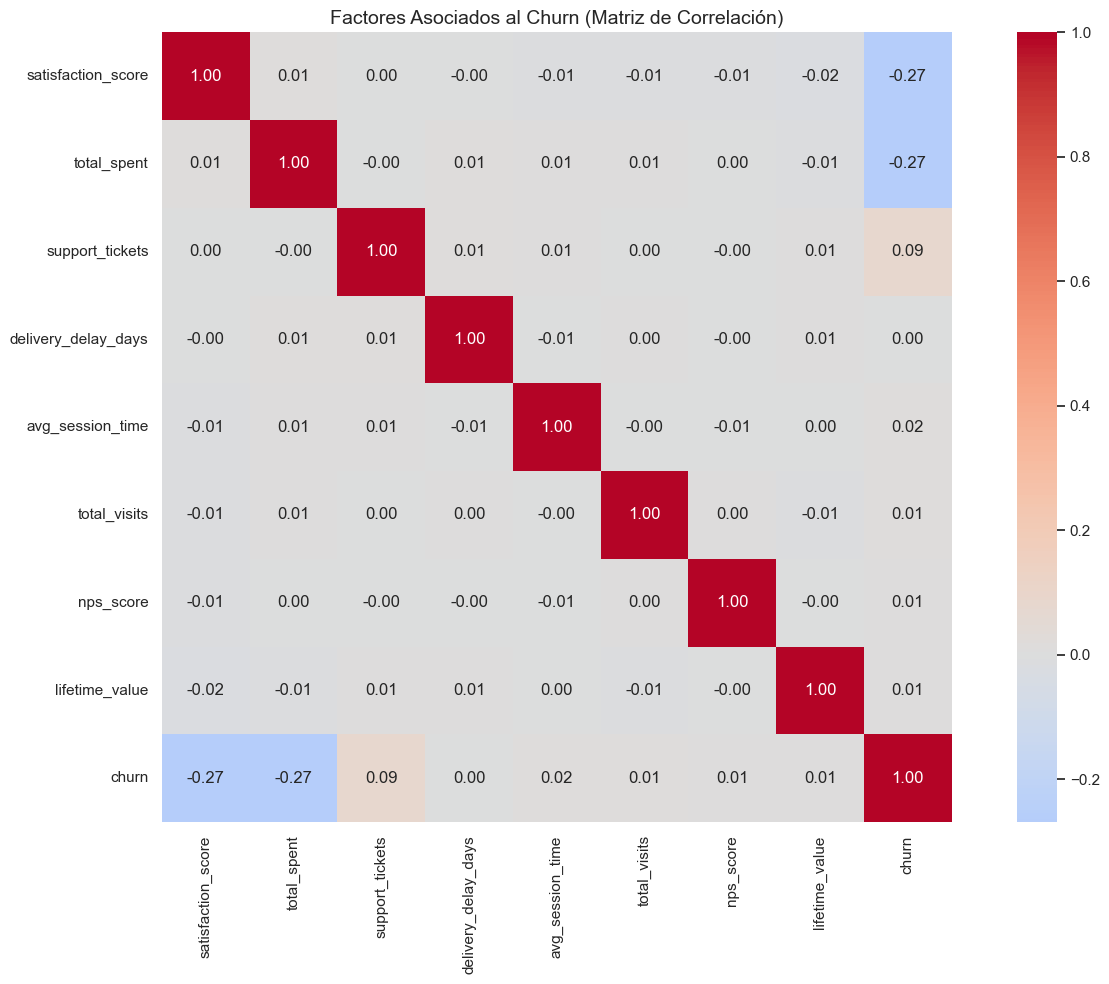


--- Generando Fig 2: Perfil Comparativo ---


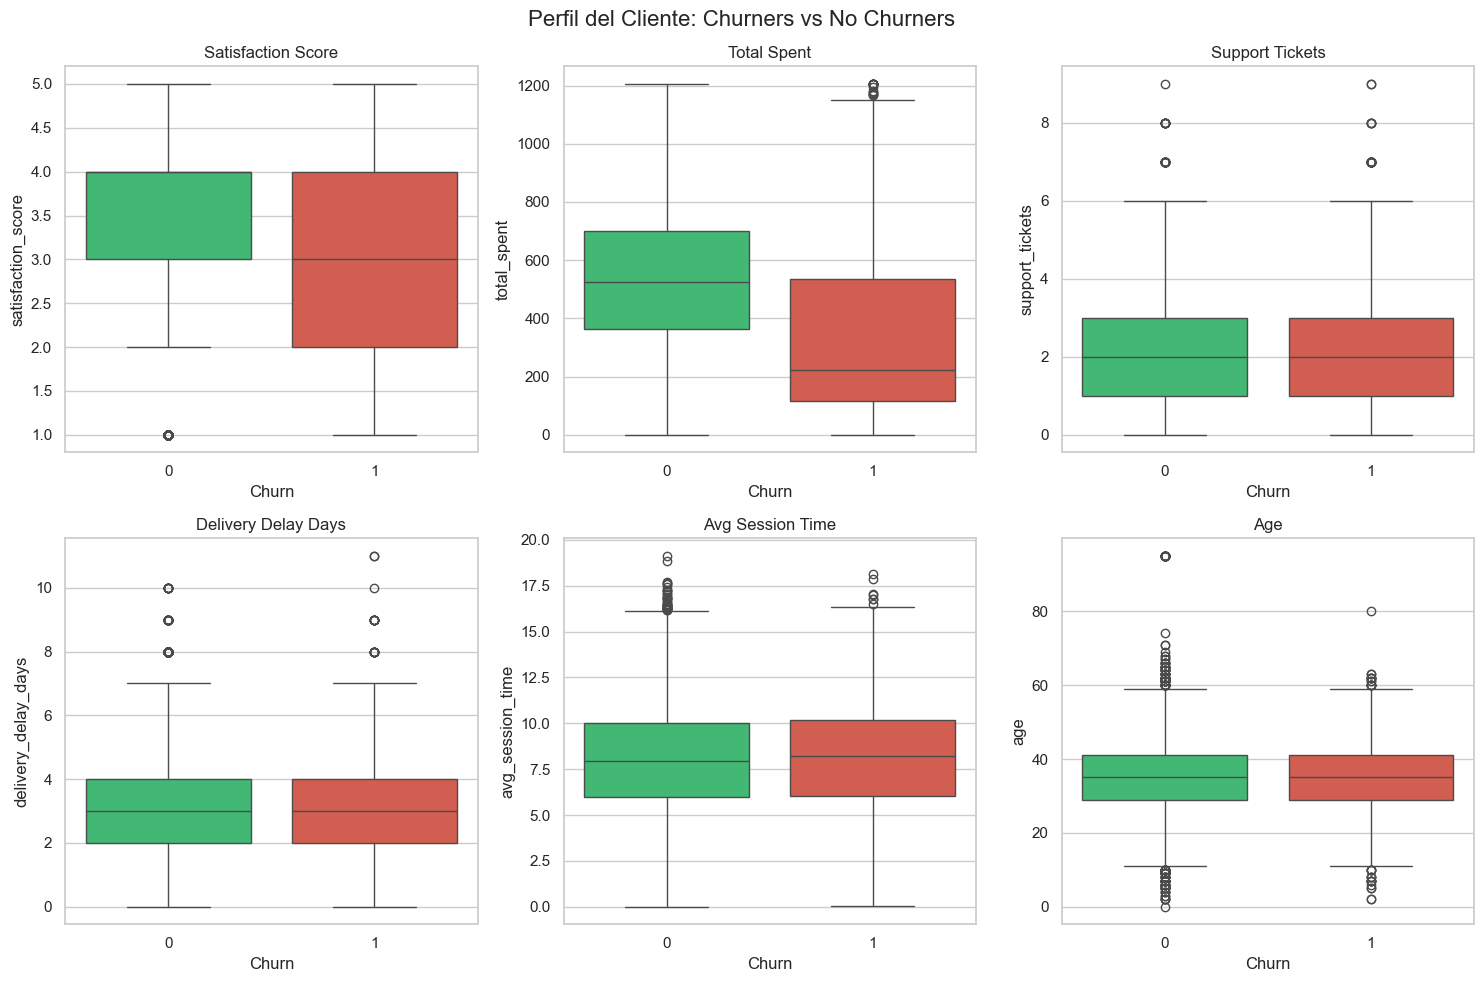


--- Generando Fig 3: LTV por Canal ---


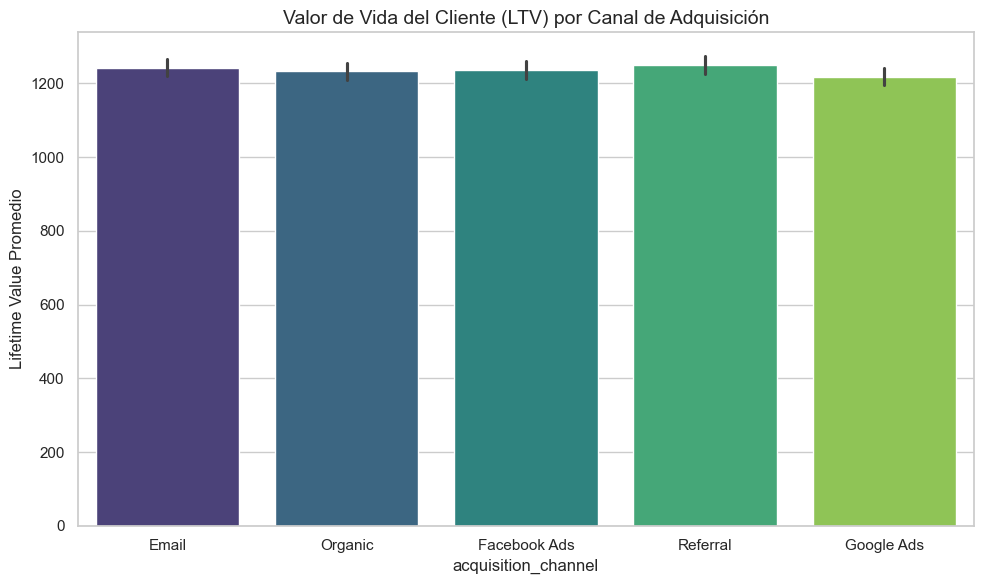


--- Generando Fig 4: Satisfacción vs Gasto ---


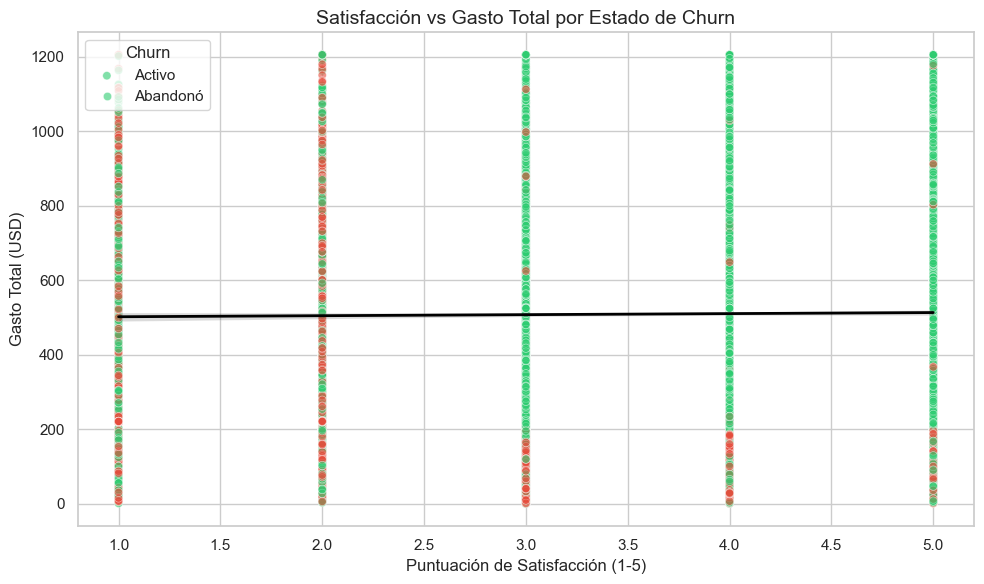


--- Generando Fig 5: Tasa de Churn por Segmento ---


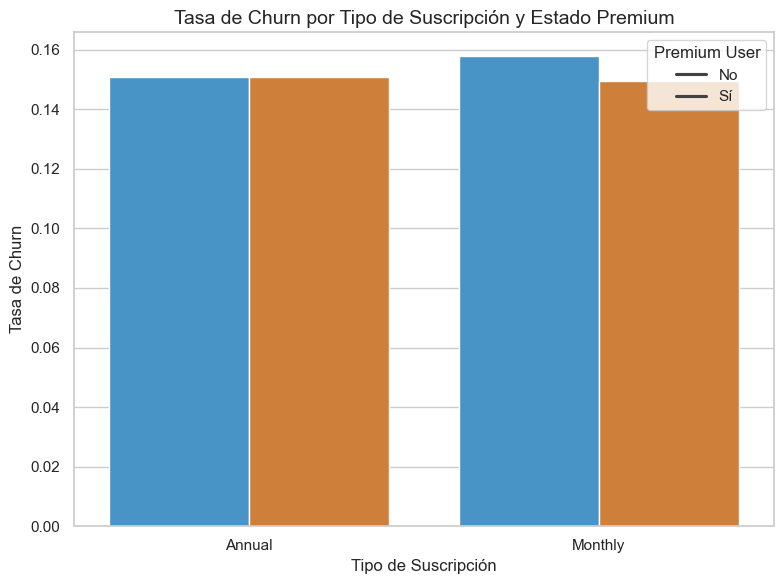

✅ 5 visualizaciones guardadas en ../reports/figures/


In [7]:
# ============================================================
# VISUALIZACIONES CLAVE (RESPONDIENDO PREGUNTAS DE NEGOCIO)
# ============================================================

import os
FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("\n" + "="*80)
print("VISUALIZACIONES CLAVE")
print("="*80)

# Usamos df_clean (antes de escalar para mejor interpretación) o df_encoded.
# Para gráficos interpretables, usamos df_clean.
plot_df = df_clean.copy()

# --- Visualización 1: ¿Por qué los clientes abandonan? (Heatmap de correlaciones) ---
print("\n--- Generando Fig 1: Heatmap de Correlaciones ---")
plt.figure(figsize=(14, 10))
corr_vars = ['satisfaction_score', 'total_spent', 'support_tickets', 'delivery_delay_days', 
             'avg_session_time', 'total_visits', 'nps_score', 'lifetime_value', 'churn']
corr_matrix = plot_df[corr_vars].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title('Factores Asociados al Churn (Matriz de Correlación)', fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig1_correlation_heatmap.png", dpi=300)
plt.show()

# --- Visualización 2: Perfil del cliente (boxplots churners vs no churners) ---
print("\n--- Generando Fig 2: Perfil Comparativo ---")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
vars_to_plot = ['satisfaction_score', 'total_spent', 'support_tickets', 'delivery_delay_days', 'avg_session_time', 'age']
for i, ax in enumerate(axes.flatten()):
    sns.boxplot(data=plot_df, x='churn', y=vars_to_plot[i], ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(vars_to_plot[i].replace('_', ' ').title())
    ax.set_xlabel('Churn')
plt.suptitle('Perfil del Cliente: Churners vs No Churners', fontsize=16)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig2_churner_profile.png", dpi=300)
plt.show()

# --- Visualización 3: LTV por canal de adquisición ---
print("\n--- Generando Fig 3: LTV por Canal ---")
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='acquisition_channel', y='lifetime_value', estimator=np.mean, palette='viridis')
plt.title('Valor de Vida del Cliente (LTV) por Canal de Adquisición', fontsize=14)
plt.ylabel('Lifetime Value Promedio')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig3_ltv_by_channel.png", dpi=300)
plt.show()

# --- Visualización 4: Satisfacción vs Gasto (color por churn) ---
print("\n--- Generando Fig 4: Satisfacción vs Gasto ---")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='satisfaction_score', y='total_spent', hue='churn', alpha=0.6, palette=['#2ecc71', '#e74c3c'])
sns.regplot(data=plot_df, x='satisfaction_score', y='total_spent', scatter=False, color='black', line_kws={'linewidth': 2})
plt.title('Satisfacción vs Gasto Total por Estado de Churn', fontsize=14)
plt.xlabel('Puntuación de Satisfacción (1-5)')
plt.ylabel('Gasto Total (USD)')
plt.legend(title='Churn', labels=['Activo', 'Abandonó'])
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig4_satisfaction_vs_spend.png", dpi=300)
plt.show()

# --- Visualización 5: Tasa de churn por segmento (suscripción premium) ---
print("\n--- Generando Fig 5: Tasa de Churn por Segmento ---")
churn_by_segment = plot_df.groupby(['subscription_type', 'is_premium_user'])['churn'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=churn_by_segment, x='subscription_type', y='churn', hue='is_premium_user', palette=['#3498db', '#e67e22'])
plt.title('Tasa de Churn por Tipo de Suscripción y Estado Premium', fontsize=14)
plt.xlabel('Tipo de Suscripción')
plt.ylabel('Tasa de Churn')
plt.legend(title='Premium User', labels=['No', 'Sí'])
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig5_churn_rate_by_segment.png", dpi=300)
plt.show()

print(f"✅ 5 visualizaciones guardadas en {FIGURES_DIR}")

# AUDITORÍA FINAL Y SELECCIÓN DE CARACTERÍSTICAS.

## Objetivo:
**Verificar que no haya fuga de datos (data leakage) y separar X (predictores) e y (target) para modelado.**

In [8]:
# ============================================================
# AUDITORÍA FINAL Y SELECCIÓN DE CARACTERÍSTICAS
# ============================================================

print("\n" + "="*80)
print("AUDITORÍA FINAL Y PREPARACIÓN PARA MODELADO")
print("="*80)

# --- 13.1 Separar X e y ---
y = df_encoded['churn']
X = df_encoded.drop(columns=['churn', 'customer_id', 'signup_date', 'last_purchase_date'], errors='ignore')

print(f"\n--- Dimensiones ---")
print(f"X: {X.shape}")
print(f"y: {y.shape}")

# --- 13.2 Dividir en entrenamiento y prueba (estratificado) ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n--- División Train/Test (80/20) ---")
print(f"Train: {X_train.shape[0]} registros")
print(f"Test: {X_test.shape[0]} registros")
print(f"Distribución de churn en train: {y_train.mean():.2%}")
print(f"Distribución de churn en test: {y_test.mean():.2%}")

# --- 13.3 Verificar consistencia (sin nulos ni infinitos) ---
print("\n--- Validación de integridad ---")
assert X_train.isnull().sum().sum() == 0, "Existen nulos en X_train"
assert X_test.isnull().sum().sum() == 0, "Existen nulos en X_test"
assert np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum() == 0, "Existen infinitos en X_train"
print("✅ Los datos están limpios y listos para modelado.")

print("\n✅ Trabajo completado!")


AUDITORÍA FINAL Y PREPARACIÓN PARA MODELADO

--- Dimensiones ---
X: (15000, 48)
y: (15000,)

--- División Train/Test (80/20) ---
Train: 12000 registros
Test: 3000 registros
Distribución de churn en train: 15.32%
Distribución de churn en test: 15.33%

--- Validación de integridad ---
✅ Los datos están limpios y listos para modelado.

✅ Trabajo completado!


# DOCUMENTACIÓN Y GUARDADO DEL DATASET PROCESADO.

## Objetivo: 

**Guardar el dataset procesado en la carpeta data/  y generar un resumen ejecutivo de la preparación.**

In [9]:
# ============================================================
# GUARDADO Y DOCUMENTACIÓN FINAL 
# ============================================================

print("\n" + "="*80)
print("GUARDADO Y DOCUMENTACIÓN")
print("="*80)

# --- 14.1 Guardar dataset INTERMEDIO (limpio, imputado, sin codificar) ---
os.makedirs(os.path.dirname(config.INTERIM_DATA_PATH), exist_ok=True)
df_clean.to_csv(config.INTERIM_DATA_PATH, index=False)
print(f"✅ Dataset intermedio guardado en: {config.INTERIM_DATA_PATH}")
print(f"   Dimensiones: {df_clean.shape}")

# --- 14.2 Guardar dataset PROCESADO (codificado y escalado) ---
os.makedirs(os.path.dirname(config.PROCESSED_DATA_PATH), exist_ok=True)
df_encoded.to_csv(config.PROCESSED_DATA_PATH, index=False)
print(f"✅ Dataset procesado guardado en: {config.PROCESSED_DATA_PATH}")
print(f"   Dimensiones finales: {df_encoded.shape}")

# --- 14.3 Resumen de variables creadas ---
print("\n--- Resumen de nuevas variables creadas ---")
new_features = ['satisfaction_risk', 'is_high_spender', 'sat_high_spender', 
                'days_since_signup', 'days_since_last_purchase', 'revenue_per_visit']
for feat in new_features:
    if feat in df_encoded.columns:
        print(f"   - {feat}: media = {df_encoded[feat].mean():.3f}, std = {df_encoded[feat].std():.3f}")

# --- 14.4 Resumen de imputaciones y escalado ---
print("\n--- Resumen de imputaciones realizadas ---")
print("   - age: mediana por grupo de churn (corregido negativo a NaN)")
print("   - total_spent: mediana por grupo de churn y winsorizado al P99")
print("   - satisfaction_score: mediana por grupo de churn")
print("   - gender: moda ('Male')")
print("   - coupon_code: categoría 'Sin cupón'")
print("   - Fechas: convertidas a días desde referencia (días desde registro/compra)")

print("\n✅ Guardado completado exitosamente.")
print("📌 Próximo paso: Modeling (entrenamiento de modelos predictivos).")

# ============================================================
#  GUARDADO DE SPLITS (TRAIN/TEST) PARA MODELADO
# ============================================================
from sklearn.model_selection import train_test_split
import joblib

if config.TARGET_COLUMN not in df_encoded.columns:
    raise ValueError(f"❌ La columna '{config.TARGET_COLUMN}' no existe.")

X = df_encoded.drop(columns=[config.TARGET_COLUMN])
y = df_encoded[config.TARGET_COLUMN]

print(f"\n🔹 X shape: {X.shape}")
print(f"🔹 y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=y
)

print(f"✅ Train size: {X_train.shape[0]:,} filas")
print(f"✅ Test size : {X_test.shape[0]:,} filas")

os.makedirs(os.path.dirname(config.X_TRAIN_PATH), exist_ok=True)

joblib.dump(X_train, config.X_TRAIN_PATH)
joblib.dump(X_test, config.X_TEST_PATH)
joblib.dump(y_train, config.Y_TRAIN_PATH)
joblib.dump(y_test, config.Y_TEST_PATH)

print("\n✅ Splits guardados correctamente en data/processed/")
print(f"   - X_train: {config.X_TRAIN_PATH}")
print(f"   - X_test : {config.X_TEST_PATH}")
print(f"   - y_train: {config.Y_TRAIN_PATH}")
print(f"   - y_test : {config.Y_TEST_PATH}")


GUARDADO Y DOCUMENTACIÓN
✅ Dataset intermedio guardado en: c:\Users\Divios\Desktop\MEACD_ML1\S1\sales-marketing-churn-analysis\data\interim\sales_marketing_clean.csv
   Dimensiones: (15000, 36)
✅ Dataset procesado guardado en: c:\Users\Divios\Desktop\MEACD_ML1\S1\sales-marketing-churn-analysis\data\processed\sales_marketing_processed.csv
   Dimensiones finales: (15000, 52)

--- Resumen de nuevas variables creadas ---
   - satisfaction_risk: media = 0.147, std = 0.354
   - is_high_spender: media = 0.500, std = 0.500
   - sat_high_spender: media = 1.813, std = 1.960
   - days_since_signup: media = 0.006, std = 0.574
   - days_since_last_purchase: media = 0.006, std = 0.572
   - revenue_per_visit: media = 0.108, std = 0.822

--- Resumen de imputaciones realizadas ---
   - age: mediana por grupo de churn (corregido negativo a NaN)
   - total_spent: mediana por grupo de churn y winsorizado al P99
   - satisfaction_score: mediana por grupo de churn
   - gender: moda ('Male')
   - coupon_cod